
== PINN: Re=196, lambda_s=0.0, eta_s=0.0, r_obs=0.25 ===
[GEOMETRY] Re=196, delta=7.14285714e-02, z_max=7.14285714e-01, eta_max=10.000
  X_obs shape: (10, 2)
  z range     : 0.0 → 0.7142857313156128
  U min/max   : -5.0486143996969176e-29 → 0.04433055967092514
  V min/max   : -0.25 → 0.0
  W min/max   : -0.06302115321159363 → 0.0
  VKD refs: F'(0)=0.510214, G'(0)=-0.615910, H_inf~H(10.0)=-0.882296
[Uniform GRID] Nr=79, Nz=64, N=5056 (target 5000)

[NOISE] Re=196, layers=4, neu=64, noise=0.0%
Compiling model...
'compile' took 0.000158 s

Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [7.56e-02, 7.54e-02, 6.76e-03, 5.52e-06, 1.37e-03, 2.49e-02, 6.79e-06, 1.28e-03, 2.27e-02, 3.82e-05, 1.79e-02, 1.52e-01]    [7.11e-02, 7.47e-02, 6.52e-03, 5.

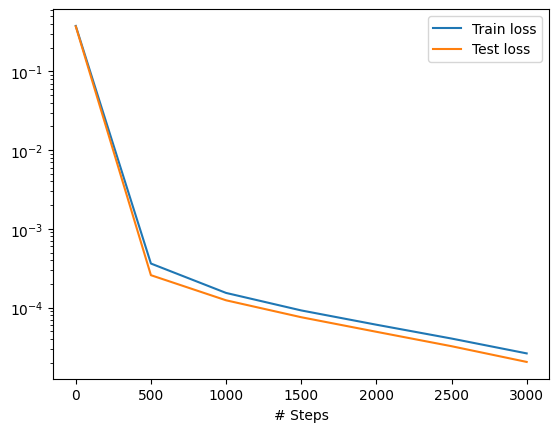

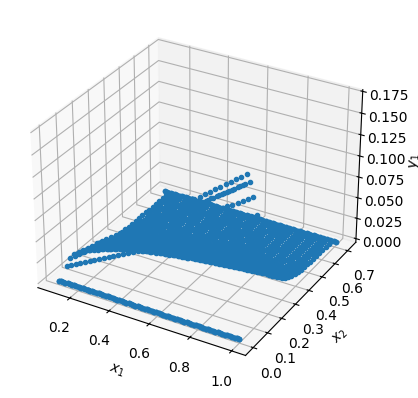

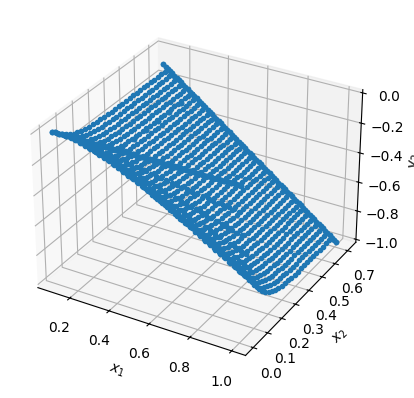

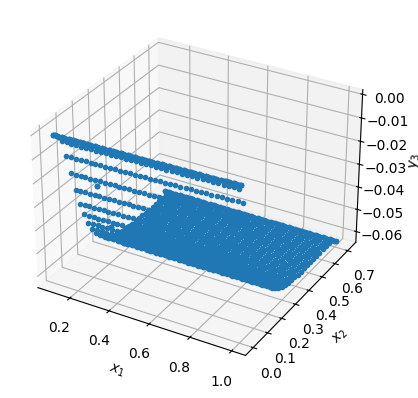

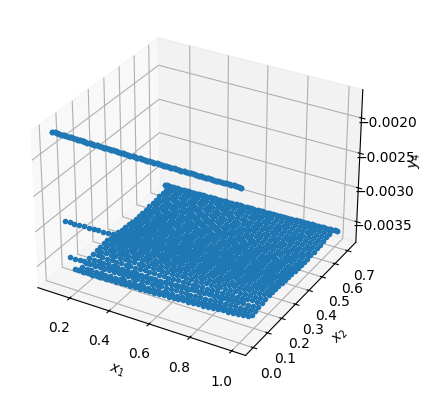

In [3]:
import os
# ⚠ DDE_BACKEND mutlaka deepxde importundan ÖNCE
os.environ["DDE_BACKEND"] = "pytorch"

import numpy as np
import torch
import torch_directml
import deepxde as dde
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import csv
from itertools import product


# =========================================
# 1) MW-von Kármán nümerik çözücü
# =========================================

def vkd_ode(eta, y):
    """
    MW benzerlik ODE sistemi:
      y[0] = F,  y[1] = F',  y[2] = G,  y[3] = G',  y[4] = H
    """
    f, fp, g, gp, h = y
    return np.vstack([
        fp,
        fp * h + f**2 - g**2,
        gp,
        gp * h + 2 * f * g,
        -2 * f,
    ])


def make_vkd_bc(lambda_slip=0.0, eta_slip=0.0, s_suction=0.0):
    """
    MW sınır şartları (η uzayında):

      F(0) = λ F'(0)          -> f(0) - λ f'(0) = 0
      G(0) - 1 = η G'(0)      -> g(0) - 1 - η g'(0) = 0
      H(0) = -2 s             -> h(0) + 2 s = 0
      F(∞) = 0                -> f(η_max) = 0
      G(∞) = 0                -> g(η_max) = 0
    """
    def vkd_bc(ya, yb):
        f0, fp0, g0, gp0, h0 = ya
        fL, fpL, gL, gpL, hL = yb
        return np.array([
            f0 - lambda_slip * fp0,
            g0 - 1.0 - eta_slip * gp0,
            h0 + 2.0 * s_suction,
            fL,
            gL,
        ])
    return vkd_bc


def solve_vkd(lambda_slip, eta_slip,
              s_suction=0.0, eta_max=10.0, n_eta=400,
              tol=1e-8, max_nodes=200000):
    """
    Verilen (λ, η, s) için benzerlik uzayında MW-von Kármán çözümü.
    """
    eta_mesh = np.linspace(0.0, eta_max, n_eta)
    y_guess = np.zeros((5, eta_mesh.size))
    y_guess[2, :] = 1.0        # G ~ 1
    y_guess[4, :] = -2.0 * s_suction

    bc = make_vkd_bc(lambda_slip=lambda_slip,
                     eta_slip=eta_slip,
                     s_suction=s_suction)

    sol = solve_bvp(vkd_ode, bc, eta_mesh, y_guess, tol=tol, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(
            f"VKD BVP solver did not converge for λ={lambda_slip}, η={eta_slip}: "
            + sol.message
        )
    return sol


def extract_vkd_refs(vk_sol, eta_far: float):
    """
    VKD çözümünden ilgili referansları çeker:
      F'(0), G'(0), H_inf ~ H(eta_far)
    """
    y0 = vk_sol.sol(np.array([0.0], dtype=np.float64))   # shape (5,1)
    yF = vk_sol.sol(np.array([eta_far], dtype=np.float64))

    Fp0 = float(y0[1, 0])       # F'(0)
    Gp0 = float(y0[3, 0])       # G'(0)
    H_inf = float(yF[4, 0])     # H(eta_far) ~ H(∞)

    return Fp0, Gp0, H_inf


def vk_profiles_dense(Re, vk_sol, r_obs=1.0, eta_plot_max=10.0, n_eta_plot=2000):
    """
    VKD çözümünü η üzerinde yoğun (dense) örnekler.
    ÇIKTI: eta_dense, z_dense, U_dense, V_dense, W_dense

    Not: PINN output_transform ile tutarlı olması için:
      U = r*F
      V = r*(G-1)
      W = δ*H   (δ = Re^{-1/2})
    """
    delta_Re = Re ** (-0.5)

    eta_dense = np.linspace(0.0, eta_plot_max, n_eta_plot)
    y_vk = vk_sol.sol(eta_dense)  # (5, n_eta_plot)

    F = y_vk[0, :]
    G = y_vk[2, :]
    H = y_vk[4, :]

    z_dense = (delta_Re * eta_dense).reshape(-1, 1)

    U_dense = (r_obs * F).reshape(-1, 1)
    V_dense = (r_obs * (G - 1.0)).reshape(-1, 1)
    W_dense = (delta_Re * H).reshape(-1, 1)  # fiziksel W

    return (eta_dense.reshape(-1, 1).astype(np.float64),
            z_dense.astype(np.float32),
            U_dense.astype(np.float32),
            V_dense.astype(np.float32),
            W_dense.astype(np.float32))


def select_obs_from_dense(eta_dense, z_dense, U_dense, V_dense, W_dense,
                          r_obs=1.0, n_obs=10):
    """
    Dense profilden n_obs adet noktayı seçer ve PINN PointSetBC formatına sokar.
    """
    N = eta_dense.shape[0]
    idx = np.linspace(0, N - 1, n_obs).astype(int)

    z_obs = z_dense[idx]  # (n_obs,1)
    U_obs = U_dense[idx]
    V_obs = V_dense[idx]
    W_obs = W_dense[idx]

    X_obs = np.hstack([
        (r_obs * np.ones_like(z_obs)),
        z_obs
    ]).astype(np.float32)

    return X_obs, U_obs, V_obs, W_obs, z_obs, idx


# =========================================
# 2) PINN
# =========================================

device = torch_directml.device()
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)



Re_list = [196]

layer_sizes = [4]
neuron_sizes = [64]
lambda_sliP = [0.0]
eta_sliP = [0.0]

# Hakem değerlendirmesi için ayrı ayrı eğitilecek gözlem yarıçapları.
# Bütün değerler [r_min, r_max] fiziksel geometrisi içinde olmalıdır.
r_obs_list = [0.25]

# ---------------------------------------------------------
# Geometri ve similarity-koordinatı ayarları
# ---------------------------------------------------------
r_min, r_max = 0.1, 1.0
z_min = 0.0

# Nümerik MW profillerinin ve feature-transform uzayının
# hedef üst sınırı. Her Reynolds sayısı için fiziksel z_max
# bu sabit eta_max değerinden hesaplanır.
eta_max = 10.0


def boundary_layer_scale(Re):
    """MW/von Karman sınır-tabakası ölçeği: delta = Re^(-1/2)."""
    return float(Re) ** (-0.5)


def zmax_from_etamax(Re, eta_max):
    """
    eta = z/delta dönüşümünde eta=eta_max olacak fiziksel üst sınır.

    z_max = delta * eta_max = eta_max / sqrt(Re)
    """
    return boundary_layer_scale(Re) * float(eta_max)


def make_feature_transform(Re):
    """Fiziksel (r,z) koordinatlarını MLP girdisi (r,eta)'ya dönüştürür."""
    delta_Re = boundary_layer_scale(Re)

    def feature_transform(x):
        r = x[:, 0:1]
        z = x[:, 1:2]
        eta = z / delta_Re
        return torch.cat([r, eta], dim=1)

    return feature_transform

# ---------------------------
# PDE
# ---------------------------
def make_pde(Re):
    def pde(x, y):
        r = x[:, 0:1]
        z = x[:, 1:2]

        U = y[:, 0:1]
        V = y[:, 1:2]
        W = y[:, 2:3]
        P = y[:, 3:4]

        U_r = dde.grad.jacobian(y, x, i=0, j=0)
        U_z = dde.grad.jacobian(y, x, i=0, j=1)
        V_r = dde.grad.jacobian(y, x, i=1, j=0)
        V_z = dde.grad.jacobian(y, x, i=1, j=1)
        W_r = dde.grad.jacobian(y, x, i=2, j=0)
        W_z = dde.grad.jacobian(y, x, i=2, j=1)
        P_r = dde.grad.jacobian(y, x, i=3, j=0)
        P_z = dde.grad.jacobian(y, x, i=3, j=1)

        U_rr = dde.grad.jacobian(U_r, x, j=0)
        U_zz = dde.grad.jacobian(U_z, x, j=1)
        V_rr = dde.grad.jacobian(V_r, x, j=0)
        V_zz = dde.grad.jacobian(V_z, x, j=1)
        W_rr = dde.grad.jacobian(W_r, x, j=0)
        W_zz = dde.grad.jacobian(W_z, x, j=1)

        # Rotating-disk PDEs
        eq1 = (1.0 / r) * (U + r * U_r) + W_z
        eq2 = U * U_r + W * U_z - (V + r) ** 2 / r - (1.0 / Re) * (
            U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)
        ) + P_r
        eq3 = U * V_r + W * V_z + (U * V) / r + 2.0 * U - (1.0 / Re) * (
            V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2)
        )
        eq4 = U * W_r + W * W_z + P_z - (1.0 / Re) * (
            (1.0 / r) * W_r + W_rr + W_zz
        )

        return [eq1, eq2, eq3, eq4]

    return pde


# =====================================================
# Gürültü fonksiyonu + relative L2 error
# =====================================================

def add_gaussian_noise(field: np.ndarray,
                       noise_level: float,
                       rng: np.random.Generator) -> np.ndarray:
    """
    field: (N,1) numpy array
    noise_level: 0.01 -> ~%1 genlikte gürültü
    """
    if noise_level <= 0.0:
        return field.copy()

    scale = np.max(np.abs(field))
    if scale == 0.0:
        scale = 1.0

    noise = noise_level * scale * rng.standard_normal(field.shape).astype(np.float32)
    return (field + noise).astype(np.float32)


def relative_L2_error(pred: np.ndarray, ref: np.ndarray) -> float:
    diff = pred - ref
    num = np.sqrt(np.sum(diff**2))
    den = np.sqrt(np.sum(ref**2))
    if den == 0.0:
        return np.nan
    return float(num / den)


# =========================================
# 3) Training cycle
# =========================================
base_dir = "MWDisk_noise_sweep"
os.makedirs(base_dir, exist_ok=True)

noise_levels = [0.0]  # isterse [0.0, 0.01, 0.02, ...]

errors_csv = os.path.join(base_dir, "noise_sweep_errors_MWDISK.csv")
if not os.path.exists(errors_csv):
    with open(errors_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Re", "r_obs",
            "n_hidden_layers", "neurons_per_layer",
            "activation", "noise_level",
            "E_U_relL2", "E_V_relL2", "E_W_relL2", "E_comb_relL2",
            "u_prime_r_obs_z0", "v_prime_r_obs_z0", "w_r_obs_zmax",
            "Rel_U", "Rel_V", "Rel_W",
            "Fp0_ref", "Gp0_ref", "Hinf_ref",
        ])


def eval_du_dz_dv_dz(net_local, r, z):
    x = torch.tensor([[r, z]], dtype=torch.float32, device=device, requires_grad=True)
    y = net_local(x)  # [U, V, W, P] (output_transform uygulanmış)
    U = y[:, 0:1]
    V = y[:, 1:2]
    dUdx = torch.autograd.grad(U, x, grad_outputs=torch.ones_like(U), retain_graph=True)[0]
    dVdx = torch.autograd.grad(V, x, grad_outputs=torch.ones_like(V), retain_graph=True)[0]
    dU_dz = dUdx[0, 1]
    dV_dz = dVdx[0, 1]
    return dU_dz.detach().cpu().item(), dV_dz.detach().cpu().item()


def build_wall_points(r_vals: np.ndarray) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_wall = np.zeros_like(r_vals, dtype=np.float32)
    return np.column_stack([r_vals, z_wall]).astype(np.float32)


def build_top_points(r_vals: np.ndarray, z_max: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_top = (z_max * np.ones_like(r_vals, dtype=np.float32))
    return np.column_stack([r_vals, z_top]).astype(np.float32)


for Re, eta_s, lambda_s, r_obs in product(
    Re_list, eta_sliP, lambda_sliP, r_obs_list
):
    if not (r_min <= float(r_obs) <= r_max):
        raise ValueError(
            f"r_obs={r_obs} fiziksel radyal aralık "
            f"[{r_min}, {r_max}] dışında."
        )

    print(
        f"\n== PINN: Re={Re}, lambda_s={lambda_s}, eta_s={eta_s}, "
        f"r_obs={r_obs} ==="
    )
    delta_Re = boundary_layer_scale(Re)
    z_max = zmax_from_etamax(Re, eta_max)

    # Fiziksel PDE geometrisi: z in [0, z_max]. Feature transform
    # sonrasında bu aralık her Re için eta in [0, eta_max] olur.
    geom = dde.geometry.Rectangle(
        [r_min, z_min],
        [r_max, z_max],
    )

    print(
        f"[GEOMETRY] Re={Re}, delta={delta_Re:.8e}, "
        f"z_max={z_max:.8e}, eta_max={eta_max:.3f}"
    )

    pde = make_pde(Re)

    # ---------------------------------------------------------
    # 1) Solve the VKD numerical solution in ETA space
    # ---------------------------------------------------------
    eta_far = eta_max
    vk_sol = solve_vkd(
        eta_slip=eta_s,
        lambda_slip=lambda_s,
        s_suction=0.0,
        eta_max=eta_far,
        n_eta=800,
        tol=1e-8,
        max_nodes=200000
    )

    # ---- Retrieve the reference values for this (lambda_s, eta_s) ----
    Fp0_ref, Gp0_ref, Hinf_ref = extract_vkd_refs(vk_sol, eta_far=eta_far)

    # ---------------------------------------------------------
    # 2) First create the dense profile, then select 10 points from the dense profile
    # ---------------------------------------------------------
    eta_dense, z_dense, U_dense, V_dense, W_dense = vk_profiles_dense(
        Re=Re,
        vk_sol=vk_sol,
        r_obs=r_obs,
        eta_plot_max=eta_far,
        n_eta_plot=2000
    )

    X_obs, U_obs_ref, V_obs_ref, W_obs_ref, z_obs, idx_obs = select_obs_from_dense(
        eta_dense=eta_dense,
        z_dense=z_dense,
        U_dense=U_dense,
        V_dense=V_dense,
        W_dense=W_dense,
        r_obs=r_obs,
        n_obs=10
    )

    print("  X_obs shape:", X_obs.shape)
    print("  z range     :", float(z_obs.min()), "→", float(z_obs.max()))
    print("  U min/max   :", float(U_obs_ref.min()), "→", float(U_obs_ref.max()))
    print("  V min/max   :", float(V_obs_ref.min()), "→", float(V_obs_ref.max()))
    print("  W min/max   :", float(W_obs_ref.min()), "→", float(W_obs_ref.max()))
    print(f"  VKD refs: F'(0)={Fp0_ref:.6f}, G'(0)={Gp0_ref:.6f}, H_inf~H({eta_far})={Hinf_ref:.6f}")

    # ---------------------------------------------------------
    # 3) Numerical solution graph: dense + selected 10 points overlay
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

    axes[0].plot(eta_dense[:, 0], U_dense[:, 0], linewidth=2, label="dense")
    axes[0].plot(eta_dense[idx_obs, 0], U_dense[idx_obs, 0], "o", label="obs(10)")
    axes[0].set_xlabel(r"$\eta$"); axes[0].set_ylabel(fr"U(r={r_obs:g},η)")
    axes[0].set_title("U (dense + obs)")

    axes[1].plot(eta_dense[:, 0], V_dense[:, 0], linewidth=2)
    axes[1].plot(eta_dense[idx_obs, 0], V_dense[idx_obs, 0], "o")
    axes[1].set_xlabel(r"$\eta$"); axes[1].set_ylabel(fr"V(r={r_obs:g},η)")
    axes[1].set_title("V (dense + obs)")

    axes[2].plot(eta_dense[:, 0], W_dense[:, 0], linewidth=2)
    axes[2].plot(eta_dense[idx_obs, 0], W_dense[idx_obs, 0], "o")
    axes[2].set_xlabel(r"$\eta$"); axes[2].set_ylabel(fr"W(r={r_obs:g},η)")
    axes[2].set_title("W (dense + obs)")

    plt.tight_layout()
    fig_dir = os.path.join(base_dir, "figs_obs")
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(
        os.path.join(
            fig_dir,
            f"vk_dense_and_obs_eta_Re{int(Re)}_lam{lambda_s}_"
            f"eta{eta_s}_robs{r_obs:.2f}.png",
        ),
        dpi=200,
    )
    plt.close(fig)

    # =====================================================
    # Uniform GRID anchors
    # =====================================================
    target_N = 5000

    r_span = float(r_max - r_min)
    L_span = float(z_max - z_min)

    Nr = max(2, int(np.round(np.sqrt(target_N * r_span / L_span))))
    Nz = max(2, int(np.round(target_N / Nr)))
    while Nr * Nz < target_N:
        Nz += 1

    r_uni = np.linspace(r_min, r_max, Nr, dtype=np.float32)
    z_uni = np.linspace(z_min, z_max, Nz, dtype=np.float32)

    RRu, ZZu = np.meshgrid(r_uni, z_uni, indexing="xy")
    domain_uniform_grid = np.column_stack([RRu.ravel(), ZZu.ravel()]).astype(np.float32)

    print(f"[Uniform GRID] Nr={Nr}, Nz={Nz}, N={domain_uniform_grid.shape[0]} (target {target_N})")

    feature_transform = make_feature_transform(Re)

    base_seed = 12345

    for l in layer_sizes:
        for neu in neuron_sizes:
            layers = [2] + [neu] * l + [4]
            act = "tanh"

            for noise_idx, noise_level in enumerate(noise_levels):
                print(f"\n[NOISE] Re={Re}, layers={l}, neu={neu}, noise={noise_level*100:.1f}%")

                rng = np.random.default_rng(base_seed + noise_idx)

                # Noisy observations (reference 10 points)
                U_obs = add_gaussian_noise(U_obs_ref, noise_level, rng)
                V_obs = add_gaussian_noise(V_obs_ref, noise_level, rng)
                W_obs = add_gaussian_noise(W_obs_ref, noise_level, rng)

                # Observation data on the selected line r=r_obs
                bc_U = dde.icbc.PointSetBC(X_obs, U_obs, component=0)
                bc_V = dde.icbc.PointSetBC(X_obs, V_obs, component=1)
                bc_W = dde.icbc.PointSetBC(X_obs, W_obs, component=2)

                # Wall and upper boundary points
                r_bc = r_uni.copy().astype(np.float32)
                X_wall = build_wall_points(r_bc)
                X_top  = build_top_points(r_bc, float(z_max))

                zeros_op = np.zeros((X_wall.shape[0], 1), dtype=np.float32)
                zeros_wall = np.zeros((len(r_bc), 1), dtype=np.float32)


                def op_wall_U_slip(x, y, *args):
                    U = y[:, 0:1]
                    U_z = dde.grad.jacobian(y, x, i=0, j=1)
                    return U - delta_Re*lambda_s * U_z

                def op_wall_V_slip(x, y, *args):
                    V = y[:, 1:2]
                    V_z = dde.grad.jacobian(y, x, i=1, j=1)
                    return V - delta_Re*eta_s* V_z

                bc_wall_U_slip = dde.icbc.PointSetOperatorBC(X_wall, zeros_op, op_wall_U_slip)
                bc_wall_V_slip = dde.icbc.PointSetOperatorBC(X_wall, zeros_op, op_wall_V_slip)
                bc_wall_W0      = dde.icbc.PointSetBC(X_wall, zeros_wall, component=2)

                # =========================================================
                # ÜST SINIR:
                #   U=0, V=-r,
                # =========================================================
                target_top_U = np.zeros((len(r_bc), 1), dtype=np.float32)
                target_top_V = (-r_bc.reshape(-1, 1)).astype(np.float32)
                target_top_W = (Hinf_ref * np.ones((len(r_bc), 1), dtype=np.float32))
    
                bc_top_U = dde.icbc.PointSetBC(X_top, target_top_U, component=0)
                bc_top_V = dde.icbc.PointSetBC(X_top, target_top_V, component=1)
                bc_top_W = dde.icbc.PointSetBC(X_top, target_top_W, component=2)

                bcs = [
                    bc_U, bc_V, bc_W,
                    bc_wall_U_slip, bc_wall_V_slip, bc_wall_W0,
                    bc_top_U, bc_top_V
                ]

                data = dde.data.PDE(
                    geom, pde, bcs,
                    num_domain=2000,
                    num_boundary=0,
                    num_test=1000,
                    anchors=None,
                )

                net = dde.nn.FNN(layers, act, "Glorot uniform")
                net.apply_feature_transform(feature_transform)

                def output_transform(x, y):
                    r = x[:, 0:1]
                    U = r * y[:, 0:1]
                    V = r * y[:, 1:2]
                    W = delta_Re * y[:, 2:3]          # fiziksel W = δ*H
                    P = (delta_Re ** 2) * y[:, 3:4]
                    return torch.cat([U, V, W, P], dim=1)

                net.apply_output_transform(output_transform)
                net.to(device)

                output_dir = os.path.join(
                    base_dir,
                    f"Re{int(Re)}_lam{lambda_s}_eta{eta_s}_"
                    f"robs{r_obs:.2f}_{neu}x{l}_noise{int(noise_level*100)}pct"
                )
                os.makedirs(output_dir, exist_ok=True)

                model = dde.Model(data, net)
                model.compile("adam", lr=5e-4)

                losshistory_adam, train_state_adam = model.train(
                    iterations=3000,
                    model_save_path=os.path.join(output_dir, "model_adam"),
                    verbose=1,
                    display_every=500,
                )
                dde.saveplot(
                    losshistory_adam, train_state_adam,
                    issave=True, isplot=True, output_dir=output_dir
                )

                


In [5]:
"""
MW PINN checkpoint hata analizi
================================

Bu kod, MW_geometri_guncellenmis.py kodunun çalıştırıldığı notebook hücresinin
ardından ayrı bir hücre olarak çalıştırılmak üzere hazırlanmıştır.

Her r_obs konumunda eğitilmiş checkpoint iki şekilde değerlendirilir:
  1) Modelin eğitildiği r = r_obs doğrusunda,
  2) Aynı modelin r = 1 doğrusunda.

Hesaplanan ölçütler:
  - u, v ve w profilleri için bağıl L2 hata (%),
  - birleşik (u,v,w) profil bağıl L2 hatası (%),
  - du/dz ve dv/dz duvar değerleri için skaler bağıl hata (%),
  - uzak alandaki w değeri için skaler bağıl hata (%).

Not: Tek bir skaler büyüklük için bağıl L2 hata, mutlak bağıl hataya eşittir.
"""

import csv
import glob
import os
import re
from itertools import product

import numpy as np
import torch


# =========================================================
# 0) ANALİZ AYARLARI
# =========================================================
N_PROFILE_EVAL = 400
REL_EPS = 1.0e-12

# Eğitim kodundaki klasör yapısı kullanılır.
ANALYSIS_BASE_DIR = globals().get("base_dir", "MWDisk_noise_sweep")
ANALYSIS_CSV = os.path.join(
    ANALYSIS_BASE_DIR,
    "MW_r_obs_checkpoint_error_analysis.csv",
)


# =========================================================
# 1) EĞİTİM HÜCRESİNDEN GELMESİ GEREKEN TANIMLAR
# =========================================================
required_from_training_cell = [
    "dde",
    "device",
    "solve_vkd",
    "boundary_layer_scale",
    "make_feature_transform",
    "Re_list",
    "eta_sliP",
    "lambda_sliP",
    "r_obs_list",
    "layer_sizes",
    "neuron_sizes",
    "noise_levels",
    "eta_max",
]

missing_names = [
    name for name in required_from_training_cell if name not in globals()
]
if missing_names:
    raise RuntimeError(
        "Önce MW eğitim hücresini çalıştırmalısınız. Eksik tanımlar: "
        + ", ".join(missing_names)
    )


# =========================================================
# 2) HATA ÖLÇÜTLERİ
# =========================================================
def relative_l2_percent(pred, ref, eps=REL_EPS):
    """Makalede kullanılan bağıl L2 hatayı yüzde olarak döndürür."""
    pred = np.asarray(pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(ref, dtype=np.float64).reshape(-1)

    numerator = np.linalg.norm(pred - ref, ord=2)
    denominator = np.linalg.norm(ref, ord=2)
    return 100.0 * numerator / max(denominator, eps)


def scalar_relative_percent(pred, ref, eps=REL_EPS):
    """Tek bir skaler değer için bağıl hatayı yüzde olarak döndürür."""
    return 100.0 * abs(float(pred) - float(ref)) / max(abs(float(ref)), eps)


# =========================================================
# 3) CHECKPOINT İÇİN AĞIN YENİDEN KURULMASI
# =========================================================
def make_analysis_output_transform(Re):
    """Eğitim kodundaki MW output transformation'ın aynısıdır."""
    delta_Re = boundary_layer_scale(Re)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_Re * y[:, 2:3]
        P = (delta_Re ** 2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    return output_transform


def build_analysis_net(Re, n_hidden_layers, neurons_per_layer):
    """Checkpoint ile aynı MLP, feature transform ve output transformı kurar."""
    layers = [2] + [int(neurons_per_layer)] * int(n_hidden_layers) + [4]

    net = dde.nn.FNN(layers, "tanh", "Glorot uniform")
    net.apply_feature_transform(make_feature_transform(Re))
    net.apply_output_transform(make_analysis_output_transform(Re))
    net.to(device)
    return net


def _extract_iteration(path):
    match = re.search(r"-(\d+)\.pt$", os.path.basename(path))
    return int(match.group(1)) if match else -1


def find_latest_checkpoint(output_dir):
    """DeepXDE'nin model_adam-<iteration>.pt dosyasını bulur."""
    candidates = glob.glob(os.path.join(output_dir, "model_adam-*.pt"))

    # Bazı kayıt düzenlerinde iteration etiketi bulunmayabilir.
    if not candidates:
        candidates = glob.glob(os.path.join(output_dir, "model_adam*.pt"))

    if not candidates:
        raise FileNotFoundError(
            f"Checkpoint bulunamadı: {output_dir}/model_adam*.pt"
        )

    return max(candidates, key=lambda path: (_extract_iteration(path), path))


def load_checkpoint_into_net(net, checkpoint_path):
    """DeepXDE checkpoint veya doğrudan state_dict biçimini yükler."""
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        # Eski PyTorch sürümleri weights_only argümanını kabul etmeyebilir.
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and all(
        torch.is_tensor(value) for value in checkpoint.values()
    ):
        state_dict = checkpoint
    else:
        raise ValueError(
            f"Desteklenmeyen checkpoint yapısı: {checkpoint_path}"
        )

    net.load_state_dict(state_dict)
    net.to(device)
    net.eval()
    return net


# =========================================================
# 4) PINN TAHMİNLERİ VE DUVAR TÜREVLERİ
# =========================================================
def predict_physical_fields(net, X):
    X_tensor = torch.as_tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        prediction = net(X_tensor)
    return prediction.detach().cpu().numpy()


def wall_normal_derivatives(net, r_eval):
    """Output transform uygulanmış fiziksel u ve v'nin z türevlerini verir."""
    x_wall = torch.tensor(
        [[float(r_eval), 0.0]],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    output = net(x_wall)
    u = output[:, 0:1]
    v = output[:, 1:2]

    grad_u = torch.autograd.grad(
        u,
        x_wall,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=False,
    )[0]
    grad_v = torch.autograd.grad(
        v,
        x_wall,
        grad_outputs=torch.ones_like(v),
        retain_graph=False,
        create_graph=False,
    )[0]

    du_dz = float(grad_u[0, 1].detach().cpu())
    dv_dz = float(grad_v[0, 1].detach().cpu())
    return du_dz, dv_dz


# =========================================================
# 5) TEK CHECKPOINT / TEK DEĞERLENDİRME YARIÇAPI
# =========================================================
def evaluate_checkpoint_at_radius(
    net,
    vk_sol,
    Re,
    r_train,
    r_eval,
    checkpoint_path,
    eta_eval_max,
    n_profile=N_PROFILE_EVAL,
):
    delta_Re = boundary_layer_scale(Re)

    eta_eval = np.linspace(
        0.0,
        float(eta_eval_max),
        int(n_profile),
        dtype=np.float64,
    )
    z_eval = delta_Re * eta_eval

    X_eval = np.column_stack(
        [
            np.full_like(z_eval, float(r_eval), dtype=np.float32),
            z_eval.astype(np.float32),
        ]
    ).astype(np.float32)

    # PINN'in output transform uygulanmış fiziksel alanları.
    pinn = predict_physical_fields(net, X_eval)
    u_pinn = pinn[:, 0]
    v_pinn = pinn[:, 1]
    w_pinn = pinn[:, 2]

    # MW nümerik çözücüsünden ortalama referans profilleri.
    y_ref = vk_sol.sol(eta_eval)
    F_ref = y_ref[0, :]
    G_ref = y_ref[2, :]
    H_ref = y_ref[4, :]

    u_ref = float(r_eval) * F_ref
    v_ref = float(r_eval) * (G_ref - 1.0)
    w_ref = delta_Re * H_ref

    E_u = relative_l2_percent(u_pinn, u_ref)
    E_v = relative_l2_percent(v_pinn, v_ref)
    E_w = relative_l2_percent(w_pinn, w_ref)

    combined_pinn = np.concatenate([u_pinn, v_pinn, w_pinn])
    combined_ref = np.concatenate([u_ref, v_ref, w_ref])
    E_combined = relative_l2_percent(combined_pinn, combined_ref)

    # Duvar-normal türevleri: d/dz = (1/delta) d/deta.
    du_dz_pinn, dv_dz_pinn = wall_normal_derivatives(net, r_eval)

    y_wall = vk_sol.sol(np.array([0.0], dtype=np.float64))
    Fp0_ref = float(y_wall[1, 0])
    Gp0_ref = float(y_wall[3, 0])

    du_dz_ref = float(r_eval) * Fp0_ref / delta_Re
    dv_dz_ref = float(r_eval) * Gp0_ref / delta_Re

    E_du_dz = scalar_relative_percent(du_dz_pinn, du_dz_ref)
    E_dv_dz = scalar_relative_percent(dv_dz_pinn, dv_dz_ref)

    # Uzak alan w değeri eta=eta_eval_max, z=z_max noktasında karşılaştırılır.
    w_far_pinn = float(w_pinn[-1])
    w_far_ref = float(w_ref[-1])
    E_w_far = scalar_relative_percent(w_far_pinn, w_far_ref)

    evaluation_type = (
        "training_radius"
        if np.isclose(float(r_eval), float(r_train))
        else "transfer_to_r1"
    )

    return {
        "Re": float(Re),
        "r_train": float(r_train),
        "r_eval": float(r_eval),
        "evaluation_type": evaluation_type,
        "checkpoint": checkpoint_path,
        "E_u_relL2_pct": E_u,
        "E_v_relL2_pct": E_v,
        "E_w_relL2_pct": E_w,
        "E_uvw_combined_relL2_pct": E_combined,
        "du_dz_PINN": du_dz_pinn,
        "du_dz_ref": du_dz_ref,
        "E_du_dz_rel_pct": E_du_dz,
        "dv_dz_PINN": dv_dz_pinn,
        "dv_dz_ref": dv_dz_ref,
        "E_dv_dz_rel_pct": E_dv_dz,
        "w_far_PINN": w_far_pinn,
        "w_far_ref": w_far_ref,
        "E_w_far_rel_pct": E_w_far,
    }


# =========================================================
# 6) BÜTÜN CHECKPOINTLERİN ANALİZİ
# =========================================================
analysis_rows = []
reference_solution_cache = {}

for Re, eta_s, lambda_s, r_train, n_hidden, neurons, noise_level in product(
    Re_list,
    eta_sliP,
    lambda_sliP,
    r_obs_list,
    layer_sizes,
    neuron_sizes,
    noise_levels,
):
    reference_key = (float(Re), float(lambda_s), float(eta_s), float(eta_max))

    if reference_key not in reference_solution_cache:
        reference_solution_cache[reference_key] = solve_vkd(
            eta_slip=eta_s,
            lambda_slip=lambda_s,
            s_suction=0.0,
            eta_max=float(eta_max),
            n_eta=800,
            tol=1.0e-8,
            max_nodes=200000,
        )

    vk_sol = reference_solution_cache[reference_key]

    output_dir = os.path.join(
        ANALYSIS_BASE_DIR,
        f"Re{int(Re)}_lam{lambda_s}_eta{eta_s}_"
        f"robs{r_train:.2f}_{neurons}x{n_hidden}_"
        f"noise{int(noise_level * 100)}pct",
    )

    checkpoint_path = find_latest_checkpoint(output_dir)

    net = build_analysis_net(
        Re=Re,
        n_hidden_layers=n_hidden,
        neurons_per_layer=neurons,
    )
    load_checkpoint_into_net(net, checkpoint_path)

    # r_train=1 ise aynı değerlendirme iki kez yapılmaz.
    evaluation_radii = [float(r_train)]
    if not np.isclose(float(r_train), 1.0):
        evaluation_radii.append(1.0)

    for r_eval in evaluation_radii:
        row = evaluate_checkpoint_at_radius(
            net=net,
            vk_sol=vk_sol,
            Re=Re,
            r_train=r_train,
            r_eval=r_eval,
            checkpoint_path=checkpoint_path,
            eta_eval_max=eta_max,
            n_profile=N_PROFILE_EVAL,
        )

        row.update(
            {
                "lambda_slip": float(lambda_s),
                "eta_slip": float(eta_s),
                "n_hidden_layers": int(n_hidden),
                "neurons_per_layer": int(neurons),
                "noise_level": float(noise_level),
                "N_profile": int(N_PROFILE_EVAL),
            }
        )
        analysis_rows.append(row)


# =========================================================
# 7) CSV KAYDI VE NOTEBOOK TABLOSU
# =========================================================
if not analysis_rows:
    raise RuntimeError("Analiz edilecek checkpoint bulunamadı.")

os.makedirs(ANALYSIS_BASE_DIR, exist_ok=True)

fieldnames = list(analysis_rows[0].keys())
with open(ANALYSIS_CSV, "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(analysis_rows)


print(f"\n[ANALYSIS COMPLETED] CSV: {ANALYSIS_CSV}")

try:
    import pandas as pd

    analysis_df = pd.DataFrame(analysis_rows)
    display_columns = [
        "Re",
        "lambda_slip",
        "eta_slip",
        "r_train",
        "r_eval",
        "evaluation_type",
        "E_u_relL2_pct",
        "E_v_relL2_pct",
        "E_w_relL2_pct",
        "E_uvw_combined_relL2_pct",
        "E_du_dz_rel_pct",
        "E_dv_dz_rel_pct",
        "E_w_far_rel_pct",
    ]

    try:
        from IPython.display import display

        display(analysis_df[display_columns])
    except ImportError:
        print(analysis_df[display_columns].to_string(index=False))

except ImportError:
    for row in analysis_rows:
        print(row)



[ANALYSIS COMPLETED] CSV: MWDisk_noise_sweep\MW_r_obs_checkpoint_error_analysis.csv


,Re,lambda_slip,eta_slip,r_train,r_eval,evaluation_type,E_u_relL2_pct,E_v_relL2_pct,E_w_relL2_pct,E_uvw_combined_relL2_pct,E_du_dz_rel_pct,E_dv_dz_rel_pct,E_w_far_rel_pct
0,196.0,0.77,0.0,0.25,0.25,training_radius,1.887961,0.263976,0.853837,0.390783,2.473855,1.245171,0.274744
1,196.0,0.77,0.0,0.25,1.00,transfer_to_r1,2.491697,0.887302,2.651493,0.935694,1.239996,2.644637,3.886276
2,196.0,0.77,0.0,0.50,0.50,training_radius,1.552957,0.212703,1.029964,0.299524,0.595107,1.130577,0.390510
3,196.0,0.77,0.0,0.50,1.00,transfer_to_r1,2.498277,0.441008,2.679570,0.541291,0.724092,3.591440,1.586886
4,196.0,0.77,0.0,0.75,0.75,training_radius,1.456626,0.077145,1.006299,0.192499,0.421133,0.497246,0.155532
5,196.0,0.77,0.0,0.75,1.00,transfer_to_r1,2.764802,0.399229,3.240552,0.538251,1.653690,3.765954,2.395026
6,196.0,0.77,0.0,1.00,1.00,training_radius,2.736680,0.190072,1.634598,0.357693,1.073827,2.755029,0.968250


In [4]:
"""
MW PINN checkpoint hata analizi
================================

Bu kod, MW_geometri_guncellenmis.py kodunun çalıştırıldığı notebook hücresinin
ardından ayrı bir hücre olarak çalıştırılmak üzere hazırlanmıştır.

Yalnızca r_train = 0.25 konumunda eğitilmiş checkpoint kullanılır ve aynı model
dört radyal konumda değerlendirilir:
  1) r_eval = 0.25: modelin eğitildiği gözlem doğrusu,
  2) r_eval = 0.50, 0.75 ve 1.00: gözlem verisi içermeyen validasyon doğruları.

Hesaplanan ölçütler:
  - u, v ve w profilleri için bağıl L2 hata (%),
  - birleşik (u,v,w) profil bağıl L2 hatası (%),
  - du/dz ve dv/dz duvar değerleri için skaler bağıl hata (%),
  - uzak alandaki w değeri için skaler bağıl hata (%).

Not: Tek bir skaler büyüklük için bağıl L2 hata, mutlak bağıl hataya eşittir.
"""

import csv
import glob
import os
import re
from itertools import product

import numpy as np
import torch


# =========================================================
# 0) ANALİZ AYARLARI
# =========================================================
N_PROFILE_EVAL = 400
REL_EPS = 1.0e-12

# Bu analizde yalnızca r=0.25'te eğitilmiş checkpoint kullanılacaktır.
ANALYSIS_R_TRAIN = 0.25
ANALYSIS_R_EVAL_LIST = [0.25, 0.50, 0.75, 1.00]

# Eğitim kodundaki klasör yapısı kullanılır.
ANALYSIS_BASE_DIR = globals().get("base_dir", "MWDisk_noise_sweep")
ANALYSIS_CSV = os.path.join(
    ANALYSIS_BASE_DIR,
    "MW_rtrain0.25_radial_transfer_error_analysis.csv",
)


# =========================================================
# 1) EĞİTİM HÜCRESİNDEN GELMESİ GEREKEN TANIMLAR
# =========================================================
required_from_training_cell = [
    "dde",
    "device",
    "solve_vkd",
    "boundary_layer_scale",
    "make_feature_transform",
    "Re_list",
    "eta_sliP",
    "lambda_sliP",
    "layer_sizes",
    "neuron_sizes",
    "noise_levels",
    "eta_max",
]

missing_names = [
    name for name in required_from_training_cell if name not in globals()
]
if missing_names:
    raise RuntimeError(
        "Önce MW eğitim hücresini çalıştırmalısınız. Eksik tanımlar: "
        + ", ".join(missing_names)
    )


# =========================================================
# 2) HATA ÖLÇÜTLERİ
# =========================================================
def relative_l2_percent(pred, ref, eps=REL_EPS):
    """Makalede kullanılan bağıl L2 hatayı yüzde olarak döndürür."""
    pred = np.asarray(pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(ref, dtype=np.float64).reshape(-1)

    numerator = np.linalg.norm(pred - ref, ord=2)
    denominator = np.linalg.norm(ref, ord=2)
    return 100.0 * numerator / max(denominator, eps)


def scalar_relative_percent(pred, ref, eps=REL_EPS):
    """Tek bir skaler değer için bağıl hatayı yüzde olarak döndürür."""
    return 100.0 * abs(float(pred) - float(ref)) / max(abs(float(ref)), eps)


# =========================================================
# 3) CHECKPOINT İÇİN AĞIN YENİDEN KURULMASI
# =========================================================
def make_analysis_output_transform(Re):
    """Eğitim kodundaki MW output transformation'ın aynısıdır."""
    delta_Re = boundary_layer_scale(Re)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_Re * y[:, 2:3]
        P = (delta_Re ** 2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    return output_transform


def build_analysis_net(Re, n_hidden_layers, neurons_per_layer):
    """Checkpoint ile aynı MLP, feature transform ve output transformı kurar."""
    layers = [2] + [int(neurons_per_layer)] * int(n_hidden_layers) + [4]

    net = dde.nn.FNN(layers, "tanh", "Glorot uniform")
    net.apply_feature_transform(make_feature_transform(Re))
    net.apply_output_transform(make_analysis_output_transform(Re))
    net.to(device)
    return net


def _extract_iteration(path):
    match = re.search(r"-(\d+)\.pt$", os.path.basename(path))
    return int(match.group(1)) if match else -1


def find_latest_checkpoint(output_dir):
    """DeepXDE'nin model_adam-<iteration>.pt dosyasını bulur."""
    candidates = glob.glob(os.path.join(output_dir, "model_adam-*.pt"))

    # Bazı kayıt düzenlerinde iteration etiketi bulunmayabilir.
    if not candidates:
        candidates = glob.glob(os.path.join(output_dir, "model_adam*.pt"))

    if not candidates:
        raise FileNotFoundError(
            f"Checkpoint bulunamadı: {output_dir}/model_adam*.pt"
        )

    return max(candidates, key=lambda path: (_extract_iteration(path), path))


def load_checkpoint_into_net(net, checkpoint_path):
    """DeepXDE checkpoint veya doğrudan state_dict biçimini yükler."""
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        # Eski PyTorch sürümleri weights_only argümanını kabul etmeyebilir.
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and all(
        torch.is_tensor(value) for value in checkpoint.values()
    ):
        state_dict = checkpoint
    else:
        raise ValueError(
            f"Desteklenmeyen checkpoint yapısı: {checkpoint_path}"
        )

    net.load_state_dict(state_dict)
    net.to(device)
    net.eval()
    return net


# =========================================================
# 4) PINN TAHMİNLERİ VE DUVAR TÜREVLERİ
# =========================================================
def predict_physical_fields(net, X):
    X_tensor = torch.as_tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        prediction = net(X_tensor)
    return prediction.detach().cpu().numpy()


def wall_normal_derivatives(net, r_eval):
    """Output transform uygulanmış fiziksel u ve v'nin z türevlerini verir."""
    x_wall = torch.tensor(
        [[float(r_eval), 0.0]],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    output = net(x_wall)
    u = output[:, 0:1]
    v = output[:, 1:2]

    grad_u = torch.autograd.grad(
        u,
        x_wall,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=False,
    )[0]
    grad_v = torch.autograd.grad(
        v,
        x_wall,
        grad_outputs=torch.ones_like(v),
        retain_graph=False,
        create_graph=False,
    )[0]

    du_dz = float(grad_u[0, 1].detach().cpu())
    dv_dz = float(grad_v[0, 1].detach().cpu())
    return du_dz, dv_dz


# =========================================================
# 5) TEK CHECKPOINT / TEK DEĞERLENDİRME YARIÇAPI
# =========================================================
def evaluate_checkpoint_at_radius(
    net,
    vk_sol,
    Re,
    r_train,
    r_eval,
    checkpoint_path,
    eta_eval_max,
    n_profile=N_PROFILE_EVAL,
):
    delta_Re = boundary_layer_scale(Re)

    eta_eval = np.linspace(
        0.0,
        float(eta_eval_max),
        int(n_profile),
        dtype=np.float64,
    )
    z_eval = delta_Re * eta_eval

    X_eval = np.column_stack(
        [
            np.full_like(z_eval, float(r_eval), dtype=np.float32),
            z_eval.astype(np.float32),
        ]
    ).astype(np.float32)

    # PINN'in output transform uygulanmış fiziksel alanları.
    pinn = predict_physical_fields(net, X_eval)
    u_pinn = pinn[:, 0]
    v_pinn = pinn[:, 1]
    w_pinn = pinn[:, 2]

    # MW nümerik çözücüsünden ortalama referans profilleri.
    y_ref = vk_sol.sol(eta_eval)
    F_ref = y_ref[0, :]
    G_ref = y_ref[2, :]
    H_ref = y_ref[4, :]

    u_ref = float(r_eval) * F_ref
    v_ref = float(r_eval) * (G_ref - 1.0)
    w_ref = delta_Re * H_ref

    E_u = relative_l2_percent(u_pinn, u_ref)
    E_v = relative_l2_percent(v_pinn, v_ref)
    E_w = relative_l2_percent(w_pinn, w_ref)

    combined_pinn = np.concatenate([u_pinn, v_pinn, w_pinn])
    combined_ref = np.concatenate([u_ref, v_ref, w_ref])
    E_combined = relative_l2_percent(combined_pinn, combined_ref)

    # Duvar-normal türevleri: d/dz = (1/delta) d/deta.
    du_dz_pinn, dv_dz_pinn = wall_normal_derivatives(net, r_eval)

    y_wall = vk_sol.sol(np.array([0.0], dtype=np.float64))
    Fp0_ref = float(y_wall[1, 0])
    Gp0_ref = float(y_wall[3, 0])

    du_dz_ref = float(r_eval) * Fp0_ref / delta_Re
    dv_dz_ref = float(r_eval) * Gp0_ref / delta_Re

    E_du_dz = scalar_relative_percent(du_dz_pinn, du_dz_ref)
    E_dv_dz = scalar_relative_percent(dv_dz_pinn, dv_dz_ref)

    # Uzak alan w değeri eta=eta_eval_max, z=z_max noktasında karşılaştırılır.
    w_far_pinn = float(w_pinn[-1])
    w_far_ref = float(w_ref[-1])
    E_w_far = scalar_relative_percent(w_far_pinn, w_far_ref)

    evaluation_type = (
        "training_radius"
        if np.isclose(float(r_eval), float(r_train))
        else "radial_transfer"
    )

    return {
        "Re": float(Re),
        "r_train": float(r_train),
        "r_eval": float(r_eval),
        "evaluation_type": evaluation_type,
        "checkpoint": checkpoint_path,
        "E_u_relL2_pct": E_u,
        "E_v_relL2_pct": E_v,
        "E_w_relL2_pct": E_w,
        "E_uvw_combined_relL2_pct": E_combined,
        "du_dz_PINN": du_dz_pinn,
        "du_dz_ref": du_dz_ref,
        "E_du_dz_rel_pct": E_du_dz,
        "dv_dz_PINN": dv_dz_pinn,
        "dv_dz_ref": dv_dz_ref,
        "E_dv_dz_rel_pct": E_dv_dz,
        "w_far_PINN": w_far_pinn,
        "w_far_ref": w_far_ref,
        "E_w_far_rel_pct": E_w_far,
    }


# =========================================================
# 6) BÜTÜN CHECKPOINTLERİN ANALİZİ
# =========================================================
analysis_rows = []
reference_solution_cache = {}

for Re, eta_s, lambda_s, r_train, n_hidden, neurons, noise_level in product(
    Re_list,
    eta_sliP,
    lambda_sliP,
    [ANALYSIS_R_TRAIN],
    layer_sizes,
    neuron_sizes,
    noise_levels,
):
    reference_key = (float(Re), float(lambda_s), float(eta_s), float(eta_max))

    if reference_key not in reference_solution_cache:
        reference_solution_cache[reference_key] = solve_vkd(
            eta_slip=eta_s,
            lambda_slip=lambda_s,
            s_suction=0.0,
            eta_max=float(eta_max),
            n_eta=800,
            tol=1.0e-8,
            max_nodes=200000,
        )

    vk_sol = reference_solution_cache[reference_key]

    output_dir = os.path.join(
        ANALYSIS_BASE_DIR,
        f"Re{int(Re)}_lam{lambda_s}_eta{eta_s}_"
        f"robs{r_train:.2f}_{neurons}x{n_hidden}_"
        f"noise{int(noise_level * 100)}pct",
    )

    checkpoint_path = find_latest_checkpoint(output_dir)

    net = build_analysis_net(
        Re=Re,
        n_hidden_layers=n_hidden,
        neurons_per_layer=neurons,
    )
    load_checkpoint_into_net(net, checkpoint_path)

    # Aynı r_train=0.25 checkpoint'i tüm validasyon yarıçaplarında kullanılır.
    for r_eval in ANALYSIS_R_EVAL_LIST:
        row = evaluate_checkpoint_at_radius(
            net=net,
            vk_sol=vk_sol,
            Re=Re,
            r_train=r_train,
            r_eval=r_eval,
            checkpoint_path=checkpoint_path,
            eta_eval_max=eta_max,
            n_profile=N_PROFILE_EVAL,
        )

        row.update(
            {
                "lambda_slip": float(lambda_s),
                "eta_slip": float(eta_s),
                "n_hidden_layers": int(n_hidden),
                "neurons_per_layer": int(neurons),
                "noise_level": float(noise_level),
                "N_profile": int(N_PROFILE_EVAL),
            }
        )
        analysis_rows.append(row)


# =========================================================
# 7) CSV KAYDI VE NOTEBOOK TABLOSU
# =========================================================
if not analysis_rows:
    raise RuntimeError("Analiz edilecek checkpoint bulunamadı.")

os.makedirs(ANALYSIS_BASE_DIR, exist_ok=True)

fieldnames = list(analysis_rows[0].keys())
with open(ANALYSIS_CSV, "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(analysis_rows)


print(f"\n[ANALYSIS COMPLETED] CSV: {ANALYSIS_CSV}")

try:
    import pandas as pd

    analysis_df = pd.DataFrame(analysis_rows)
    display_columns = [
        "Re",
        "lambda_slip",
        "eta_slip",
        "r_train",
        "r_eval",
        "evaluation_type",
        "E_u_relL2_pct",
        "E_v_relL2_pct",
        "E_w_relL2_pct",
    ]

    try:
        from IPython.display import display

        display(analysis_df[display_columns])
    except ImportError:
        print(analysis_df[display_columns].to_string(index=False))

except ImportError:
    for row in analysis_rows:
        print(row)


[ANALYSIS COMPLETED] CSV: MWDisk_noise_sweep\MW_rtrain0.25_radial_transfer_error_analysis.csv


,Re,lambda_slip,eta_slip,r_train,r_eval,evaluation_type,E_u_relL2_pct,E_v_relL2_pct,E_w_relL2_pct
0,196.0,0.0,0.0,0.25,0.25,training_radius,2.220897,0.223230,0.938523
1,196.0,0.0,0.0,0.25,0.50,radial_transfer,1.834060,0.385382,0.899023
2,196.0,0.0,0.0,0.25,0.75,radial_transfer,2.056767,0.498085,1.041788
3,196.0,0.0,0.0,0.25,1.00,radial_transfer,2.594390,0.480837,1.462203


In [7]:
"""
MW PINN checkpoint hata analizi
================================

Bu kod, MW_geometri_guncellenmis.py kodunun çalıştırıldığı notebook hücresinin
ardından ayrı bir hücre olarak çalıştırılmak üzere hazırlanmıştır.

Yalnızca r_train = 0.25 konumunda eğitilmiş checkpoint kullanılır ve aynı model
dört radyal konumda değerlendirilir:
  1) r_eval = 0.25: modelin eğitildiği gözlem doğrusu,
  2) r_eval = 0.50, 0.75 ve 1.00: gözlem verisi içermeyen validasyon doğruları.

Analiz edilecek lambda_s ve eta_s değerleri bu hücrenin başındaki
ANALYSIS_LAMBDA_S_LIST ve ANALYSIS_ETA_S_LIST listelerinden belirlenir.
ANALYSIS_SLIP_LIST_MODE = "paired" seçildiğinde aynı indisli değerler bir çift
olarak analiz edilir. "cartesian" seçildiğinde iki listenin bütün kombinasyonları
analiz edilir.

Hesaplanan ölçütler:
  - u, v ve w profilleri için bağıl L2 hata (%),
  - birleşik (u,v,w) profil bağıl L2 hatası (%),
  - du/dz ve dv/dz duvar değerleri için skaler bağıl hata (%),
  - uzak alandaki w değeri için skaler bağıl hata (%).

Not: Tek bir skaler büyüklük için bağıl L2 hata, mutlak bağıl hataya eşittir.
"""

import csv
import glob
import os
import re
from itertools import product

import numpy as np
import torch


# =========================================================
# 0) ANALİZ AYARLARI
# =========================================================
N_PROFILE_EVAL = 400
REL_EPS = 1.0e-12

# Bu analizde yalnızca r=0.25'te eğitilmiş checkpoint kullanılacaktır.
ANALYSIS_R_TRAIN = 0.25
ANALYSIS_R_EVAL_LIST = [0.25, 0.50, 0.75, 1.00]

# Analiz edilecek slip parametreleri.
# Birden fazla eşleştirilmiş durum için örnek:
# ANALYSIS_LAMBDA_S_LIST = [0.0, 0.77]
# ANALYSIS_ETA_S_LIST = [0.0, 0.0]
ANALYSIS_LAMBDA_S_LIST = [0.0]
ANALYSIS_ETA_S_LIST = [0.0]

# "paired": Aynı indisli (lambda_s, eta_s) değerleri birlikte kullanılır.
# "cartesian": İki listenin bütün lambda_s x eta_s kombinasyonları kullanılır.
ANALYSIS_SLIP_LIST_MODE = "paired"

# Eğitim kodundaki klasör yapısı kullanılır.
ANALYSIS_BASE_DIR = globals().get("base_dir", "MWDisk_noise_sweep")
ANALYSIS_CSV = os.path.join(
    ANALYSIS_BASE_DIR,
    "MW_slip_parameter_radial_transfer_error_analysis.csv",
)


# =========================================================
# 1) EĞİTİM HÜCRESİNDEN GELMESİ GEREKEN TANIMLAR
# =========================================================
required_from_training_cell = [
    "dde",
    "device",
    "solve_vkd",
    "boundary_layer_scale",
    "make_feature_transform",
    "Re_list",
    "layer_sizes",
    "neuron_sizes",
    "noise_levels",
    "eta_max",
]

missing_names = [
    name for name in required_from_training_cell if name not in globals()
]
if missing_names:
    raise RuntimeError(
        "Önce MW eğitim hücresini çalıştırmalısınız. Eksik tanımlar: "
        + ", ".join(missing_names)
    )


def build_slip_parameter_pairs(lambda_values, eta_values, mode="paired"):
    """Analiz edilecek (lambda_s, eta_s) çiftlerini oluşturur."""
    lambda_values = [float(value) for value in lambda_values]
    eta_values = [float(value) for value in eta_values]
    mode = str(mode).strip().lower()

    if not lambda_values:
        raise ValueError("ANALYSIS_LAMBDA_S_LIST boş olamaz.")
    if not eta_values:
        raise ValueError("ANALYSIS_ETA_S_LIST boş olamaz.")

    if mode == "paired":
        if len(lambda_values) != len(eta_values):
            raise ValueError(
                "ANALYSIS_SLIP_LIST_MODE='paired' iken lambda_s ve eta_s "
                "listeleri aynı uzunlukta olmalıdır."
            )
        parameter_pairs = list(zip(lambda_values, eta_values))
    elif mode == "cartesian":
        parameter_pairs = list(product(lambda_values, eta_values))
    else:
        raise ValueError(
            "ANALYSIS_SLIP_LIST_MODE yalnızca 'paired' veya 'cartesian' olabilir."
        )

    # Tekrarlanan parametre çiftlerini sıra bozulmadan kaldır.
    unique_pairs = []
    for pair in parameter_pairs:
        if pair not in unique_pairs:
            unique_pairs.append(pair)
    return unique_pairs


# =========================================================
# 2) HATA ÖLÇÜTLERİ
# =========================================================
def relative_l2_percent(pred, ref, eps=REL_EPS):
    """Makalede kullanılan bağıl L2 hatayı yüzde olarak döndürür."""
    pred = np.asarray(pred, dtype=np.float64).reshape(-1)
    ref = np.asarray(ref, dtype=np.float64).reshape(-1)

    numerator = np.linalg.norm(pred - ref, ord=2)
    denominator = np.linalg.norm(ref, ord=2)
    return 100.0 * numerator / max(denominator, eps)


def scalar_relative_percent(pred, ref, eps=REL_EPS):
    """Tek bir skaler değer için bağıl hatayı yüzde olarak döndürür."""
    return 100.0 * abs(float(pred) - float(ref)) / max(abs(float(ref)), eps)


# =========================================================
# 3) CHECKPOINT İÇİN AĞIN YENİDEN KURULMASI
# =========================================================
def make_analysis_output_transform(Re):
    """Eğitim kodundaki MW output transformation'ın aynısıdır."""
    delta_Re = boundary_layer_scale(Re)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_Re * y[:, 2:3]
        P = (delta_Re ** 2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    return output_transform


def build_analysis_net(Re, n_hidden_layers, neurons_per_layer):
    """Checkpoint ile aynı MLP, feature transform ve output transformı kurar."""
    layers = [2] + [int(neurons_per_layer)] * int(n_hidden_layers) + [4]

    net = dde.nn.FNN(layers, "tanh", "Glorot uniform")
    net.apply_feature_transform(make_feature_transform(Re))
    net.apply_output_transform(make_analysis_output_transform(Re))
    net.to(device)
    return net


def _extract_iteration(path):
    match = re.search(r"-(\d+)\.pt$", os.path.basename(path))
    return int(match.group(1)) if match else -1


def find_latest_checkpoint(output_dir):
    """DeepXDE'nin model_adam-<iteration>.pt dosyasını bulur."""
    candidates = glob.glob(os.path.join(output_dir, "model_adam-*.pt"))

    # Bazı kayıt düzenlerinde iteration etiketi bulunmayabilir.
    if not candidates:
        candidates = glob.glob(os.path.join(output_dir, "model_adam*.pt"))

    if not candidates:
        raise FileNotFoundError(
            f"Checkpoint bulunamadı: {output_dir}/model_adam*.pt"
        )

    return max(candidates, key=lambda path: (_extract_iteration(path), path))


def load_checkpoint_into_net(net, checkpoint_path):
    """DeepXDE checkpoint veya doğrudan state_dict biçimini yükler."""
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )
    except TypeError:
        # Eski PyTorch sürümleri weights_only argümanını kabul etmeyebilir.
        checkpoint = torch.load(checkpoint_path, map_location="cpu")

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    elif isinstance(checkpoint, dict) and all(
        torch.is_tensor(value) for value in checkpoint.values()
    ):
        state_dict = checkpoint
    else:
        raise ValueError(
            f"Desteklenmeyen checkpoint yapısı: {checkpoint_path}"
        )

    net.load_state_dict(state_dict)
    net.to(device)
    net.eval()
    return net


# =========================================================
# 4) PINN TAHMİNLERİ VE DUVAR TÜREVLERİ
# =========================================================
def predict_physical_fields(net, X):
    X_tensor = torch.as_tensor(X, dtype=torch.float32, device=device)
    with torch.no_grad():
        prediction = net(X_tensor)
    return prediction.detach().cpu().numpy()


def wall_normal_derivatives(net, r_eval):
    """Output transform uygulanmış fiziksel u ve v'nin z türevlerini verir."""
    x_wall = torch.tensor(
        [[float(r_eval), 0.0]],
        dtype=torch.float32,
        device=device,
        requires_grad=True,
    )

    output = net(x_wall)
    u = output[:, 0:1]
    v = output[:, 1:2]

    grad_u = torch.autograd.grad(
        u,
        x_wall,
        grad_outputs=torch.ones_like(u),
        retain_graph=True,
        create_graph=False,
    )[0]
    grad_v = torch.autograd.grad(
        v,
        x_wall,
        grad_outputs=torch.ones_like(v),
        retain_graph=False,
        create_graph=False,
    )[0]

    du_dz = float(grad_u[0, 1].detach().cpu())
    dv_dz = float(grad_v[0, 1].detach().cpu())
    return du_dz, dv_dz


# =========================================================
# 5) TEK CHECKPOINT / TEK DEĞERLENDİRME YARIÇAPI
# =========================================================
def evaluate_checkpoint_at_radius(
    net,
    vk_sol,
    Re,
    r_train,
    r_eval,
    checkpoint_path,
    eta_eval_max,
    n_profile=N_PROFILE_EVAL,
):
    delta_Re = boundary_layer_scale(Re)

    eta_eval = np.linspace(
        0.0,
        float(eta_eval_max),
        int(n_profile),
        dtype=np.float64,
    )
    z_eval = delta_Re * eta_eval

    X_eval = np.column_stack(
        [
            np.full_like(z_eval, float(r_eval), dtype=np.float32),
            z_eval.astype(np.float32),
        ]
    ).astype(np.float32)

    # PINN'in output transform uygulanmış fiziksel alanları.
    pinn = predict_physical_fields(net, X_eval)
    u_pinn = pinn[:, 0]
    v_pinn = pinn[:, 1]
    w_pinn = pinn[:, 2]

    # MW nümerik çözücüsünden ortalama referans profilleri.
    y_ref = vk_sol.sol(eta_eval)
    F_ref = y_ref[0, :]
    G_ref = y_ref[2, :]
    H_ref = y_ref[4, :]

    u_ref = float(r_eval) * F_ref
    v_ref = float(r_eval) * (G_ref - 1.0)
    w_ref = delta_Re * H_ref

    E_u = relative_l2_percent(u_pinn, u_ref)
    E_v = relative_l2_percent(v_pinn, v_ref)
    E_w = relative_l2_percent(w_pinn, w_ref)

    combined_pinn = np.concatenate([u_pinn, v_pinn, w_pinn])
    combined_ref = np.concatenate([u_ref, v_ref, w_ref])
    E_combined = relative_l2_percent(combined_pinn, combined_ref)

    # Duvar-normal türevleri: d/dz = (1/delta) d/deta.
    du_dz_pinn, dv_dz_pinn = wall_normal_derivatives(net, r_eval)

    y_wall = vk_sol.sol(np.array([0.0], dtype=np.float64))
    Fp0_ref = float(y_wall[1, 0])
    Gp0_ref = float(y_wall[3, 0])

    du_dz_ref = float(r_eval) * Fp0_ref / delta_Re
    dv_dz_ref = float(r_eval) * Gp0_ref / delta_Re

    E_du_dz = scalar_relative_percent(du_dz_pinn, du_dz_ref)
    E_dv_dz = scalar_relative_percent(dv_dz_pinn, dv_dz_ref)

    # Uzak alan w değeri eta=eta_eval_max, z=z_max noktasında karşılaştırılır.
    w_far_pinn = float(w_pinn[-1])
    w_far_ref = float(w_ref[-1])
    E_w_far = scalar_relative_percent(w_far_pinn, w_far_ref)

    evaluation_type = (
        "training_radius"
        if np.isclose(float(r_eval), float(r_train))
        else "radial_transfer"
    )

    return {
        "Re": float(Re),
        "r_train": float(r_train),
        "r_eval": float(r_eval),
        "evaluation_type": evaluation_type,
        "checkpoint": checkpoint_path,
        "E_u_relL2_pct": E_u,
        "E_v_relL2_pct": E_v,
        "E_w_relL2_pct": E_w,
        "E_uvw_combined_relL2_pct": E_combined,
        "du_dz_PINN": du_dz_pinn,
        "du_dz_ref": du_dz_ref,
        "E_du_dz_rel_pct": E_du_dz,
        "dv_dz_PINN": dv_dz_pinn,
        "dv_dz_ref": dv_dz_ref,
        "E_dv_dz_rel_pct": E_dv_dz,
        "w_far_PINN": w_far_pinn,
        "w_far_ref": w_far_ref,
        "E_w_far_rel_pct": E_w_far,
    }


# =========================================================
# 6) BÜTÜN CHECKPOINTLERİN ANALİZİ
# =========================================================
analysis_rows = []
reference_solution_cache = {}

analysis_slip_pairs = build_slip_parameter_pairs(
    ANALYSIS_LAMBDA_S_LIST,
    ANALYSIS_ETA_S_LIST,
    ANALYSIS_SLIP_LIST_MODE,
)

for Re, slip_pair, r_train, n_hidden, neurons, noise_level in product(
    Re_list,
    analysis_slip_pairs,
    [ANALYSIS_R_TRAIN],
    layer_sizes,
    neuron_sizes,
    noise_levels,
):
    lambda_s, eta_s = slip_pair
    reference_key = (float(Re), float(lambda_s), float(eta_s), float(eta_max))

    if reference_key not in reference_solution_cache:
        reference_solution_cache[reference_key] = solve_vkd(
            eta_slip=eta_s,
            lambda_slip=lambda_s,
            s_suction=0.0,
            eta_max=float(eta_max),
            n_eta=800,
            tol=1.0e-8,
            max_nodes=200000,
        )

    vk_sol = reference_solution_cache[reference_key]

    output_dir = os.path.join(
        ANALYSIS_BASE_DIR,
        f"Re{int(Re)}_lam{lambda_s}_eta{eta_s}_"
        f"robs{r_train:.2f}_{neurons}x{n_hidden}_"
        f"noise{int(noise_level * 100)}pct",
    )

    checkpoint_path = find_latest_checkpoint(output_dir)

    net = build_analysis_net(
        Re=Re,
        n_hidden_layers=n_hidden,
        neurons_per_layer=neurons,
    )
    load_checkpoint_into_net(net, checkpoint_path)

    # Aynı r_train=0.25 checkpoint'i tüm validasyon yarıçaplarında kullanılır.
    for r_eval in ANALYSIS_R_EVAL_LIST:
        row = evaluate_checkpoint_at_radius(
            net=net,
            vk_sol=vk_sol,
            Re=Re,
            r_train=r_train,
            r_eval=r_eval,
            checkpoint_path=checkpoint_path,
            eta_eval_max=eta_max,
            n_profile=N_PROFILE_EVAL,
        )

        row.update(
            {
                "lambda_slip": float(lambda_s),
                "eta_slip": float(eta_s),
                "n_hidden_layers": int(n_hidden),
                "neurons_per_layer": int(neurons),
                "noise_level": float(noise_level),
                "N_profile": int(N_PROFILE_EVAL),
            }
        )
        analysis_rows.append(row)


# =========================================================
# 7) CSV KAYDI VE NOTEBOOK TABLOSU
# =========================================================
if not analysis_rows:
    raise RuntimeError("Analiz edilecek checkpoint bulunamadı.")

os.makedirs(ANALYSIS_BASE_DIR, exist_ok=True)

fieldnames = list(analysis_rows[0].keys())
with open(ANALYSIS_CSV, "w", newline="", encoding="utf-8") as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(analysis_rows)


print(f"\n[ANALYSIS COMPLETED] CSV: {ANALYSIS_CSV}")

try:
    import pandas as pd

    analysis_df = pd.DataFrame(analysis_rows)
    display_columns = [
        "Re",
        "lambda_slip",
        "eta_slip",
        "r_train",
        "r_eval",
        "evaluation_type",
        "E_u_relL2_pct",
        "E_v_relL2_pct",
        "E_w_relL2_pct",
        "E_du_dz_rel_pct",
        "E_dv_dz_rel_pct",
        "E_w_far_rel_pct",
    ]

    try:
        from IPython.display import display

        display(analysis_df[display_columns])
    except ImportError:
        print(analysis_df[display_columns].to_string(index=False))

except ImportError:
    for row in analysis_rows:
        print(row)


[ANALYSIS COMPLETED] CSV: MWDisk_noise_sweep\MW_slip_parameter_radial_transfer_error_analysis.csv


,Re,lambda_slip,eta_slip,r_train,r_eval,evaluation_type,E_u_relL2_pct,E_v_relL2_pct,E_w_relL2_pct,E_du_dz_rel_pct,E_dv_dz_rel_pct,E_w_far_rel_pct
0,196.0,0.0,0.0,0.25,0.25,training_radius,2.220897,0.223230,0.938523,1.626046,0.667791,0.117153
1,196.0,0.0,0.0,0.25,0.50,radial_transfer,1.834060,0.385382,0.899023,0.556422,1.116373,0.167551
2,196.0,0.0,0.0,0.25,0.75,radial_transfer,2.056767,0.498085,1.041788,0.687366,0.397219,0.253370
3,196.0,0.0,0.0,0.25,1.00,radial_transfer,2.594390,0.480837,1.462203,2.240312,1.342331,0.363459
